In [1]:
%matplotlib ipympl

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from nested.optimize_utils import PopulationAnnealing, OptimizationHistory, OptimizationReport

In [3]:
param_names = ['x', 'y']
bounds = [(-10., 10.), (-10., 10.)]

feature_names = []
objective_names = ['f1', 'f2']

def evaluate_example_model(parameters, **kwargs):
    x, y = parameters
        
    f1 = 0.125*(20. + x + y)**2.
    f2 = 100. + x*y
    
    features = dict()

    features = {'f1': f1, 'f2': f2}
    objectives = dict(features)
    return features, objectives

In [4]:
param_gen = PopulationAnnealing(bounds=bounds, param_names=param_names, feature_names=feature_names, 
                                objective_names=objective_names, pop_size=1, path_length=1, max_iter=20)

RelativeBoundedStep: starting parameters not specified; choosing random initial parameters.


In [5]:
param_gen.x0

array([3.85621811, 2.59456367])

In [6]:
param_gen_iter = iter(param_gen())

In [7]:
result = next(param_gen_iter)

In [8]:
type(result), type(result[0]), type(result[1])

(tuple, list, list)

In [9]:
population, model_ids = result
print(population, model_ids)

[array([3.85621811, 2.59456367])] [0]


In [10]:
features, objectives = evaluate_example_model(population[0])
features_list = [features]
objectives_list = [objectives]
param_gen.update_population(features_list, objectives_list)

In [11]:
next(param_gen_iter)

([array([3.54142273, 3.10416741])], [1])

In [12]:
history_file_path = 'data/example_optimization_history.hdf5'

In [13]:
param_gen = PopulationAnnealing(bounds=bounds, param_names=param_names, feature_names=feature_names, 
                                objective_names=objective_names, pop_size=50, path_length=1, max_iter=20, history_file_path=history_file_path)

RelativeBoundedStep: starting parameters not specified; choosing random initial parameters.


In [14]:
for population, model_ids in param_gen():
    features_list, objectives_list = [], []
    for params in population:
        features, objectives = evaluate_example_model(params)
        features_list.append(features)
        objectives_list.append(objectives)
    param_gen.update_population(features_list, objectives_list)

OptimizationHistory: generation 0 already exported to file.
OptimizationHistory: saving 1 generations (up to generation 0) to file: data/example_optimization_history.hdf5 took 0.00 s
OptimizationHistory: generation 1 already exported to file.
OptimizationHistory: saving 1 generations (up to generation 1) to file: data/example_optimization_history.hdf5 took 0.00 s
OptimizationHistory: generation 2 already exported to file.
OptimizationHistory: saving 1 generations (up to generation 2) to file: data/example_optimization_history.hdf5 took 0.00 s
OptimizationHistory: generation 3 already exported to file.
OptimizationHistory: saving 1 generations (up to generation 3) to file: data/example_optimization_history.hdf5 took 0.00 s
OptimizationHistory: generation 4 already exported to file.
OptimizationHistory: saving 1 generations (up to generation 4) to file: data/example_optimization_history.hdf5 took 0.00 s
OptimizationHistory: generation 5 already exported to file.
OptimizationHistory: savi

In [15]:
history = OptimizationHistory(file_path=history_file_path)

OptimizationHistory: loading 20 generations from file: data/example_optimization_history.hdf5 took 1.44 s


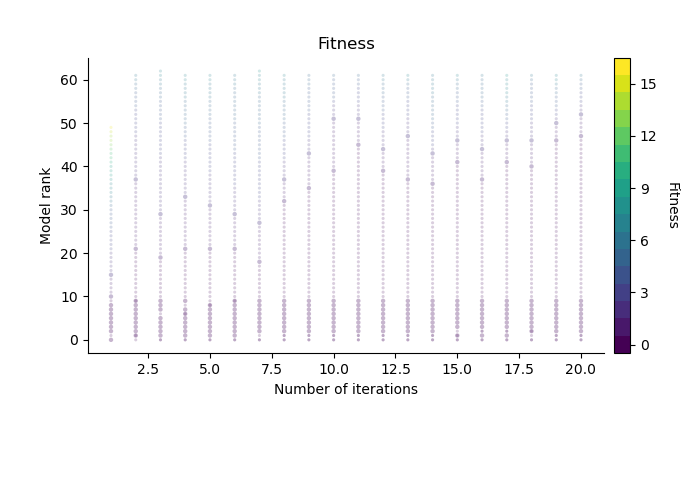

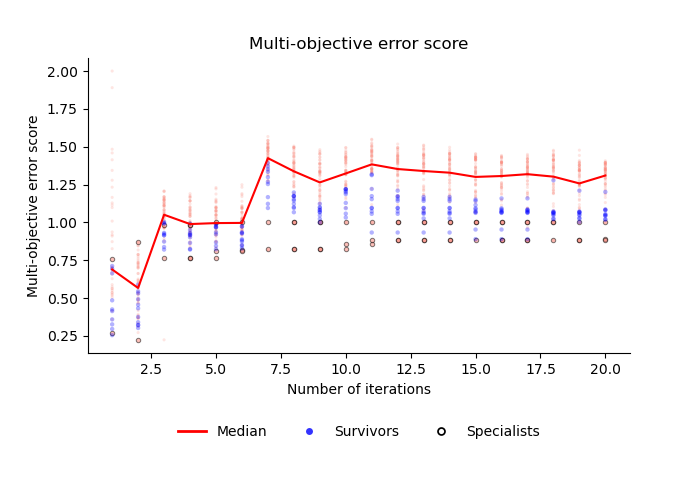

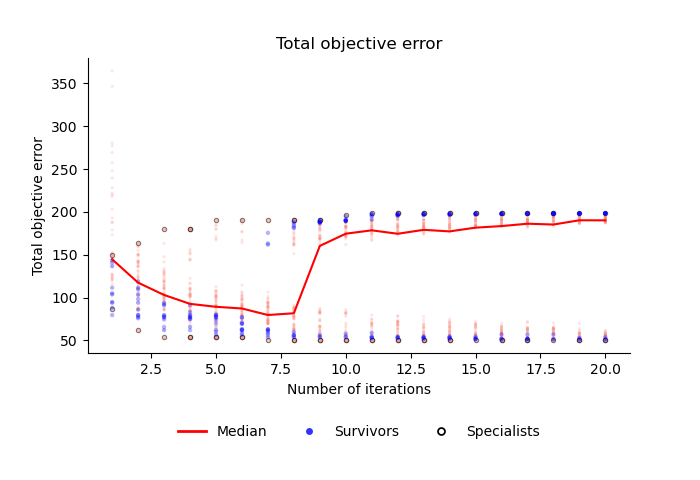

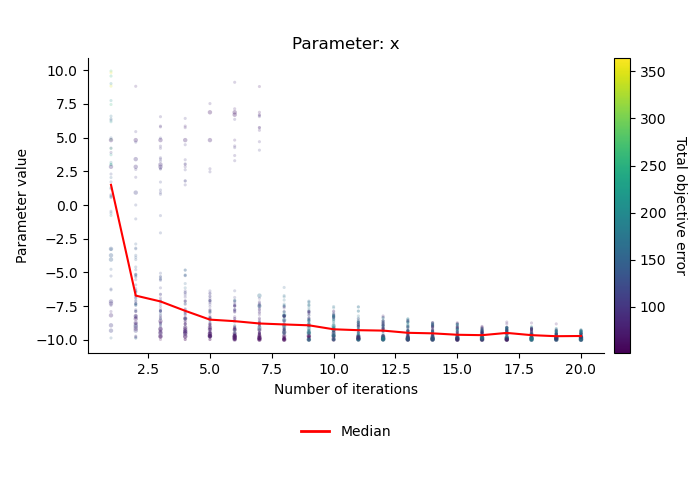

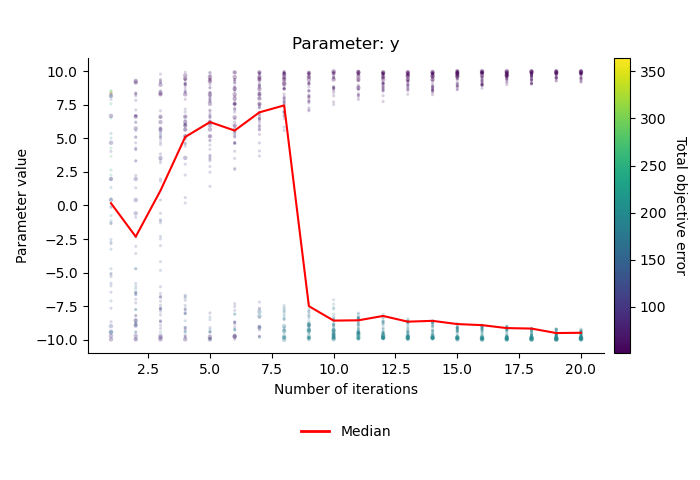

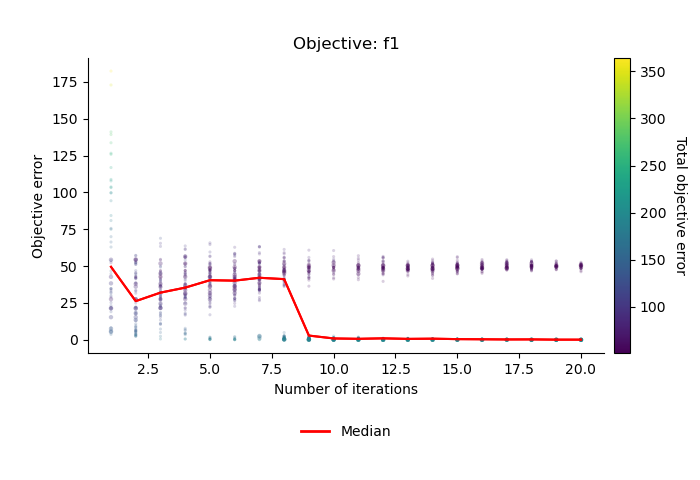

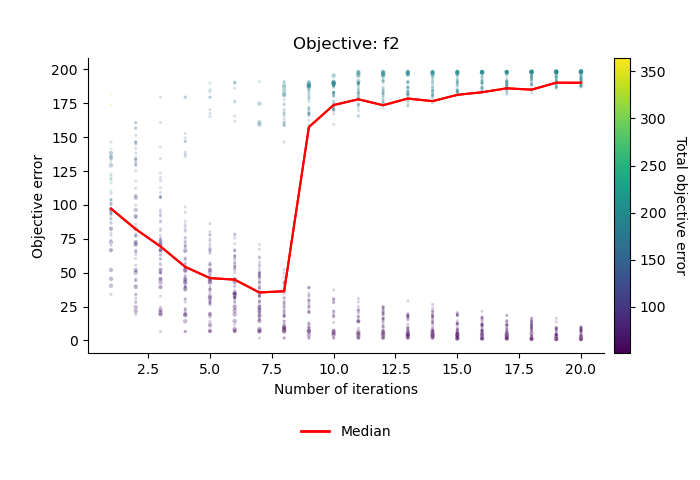

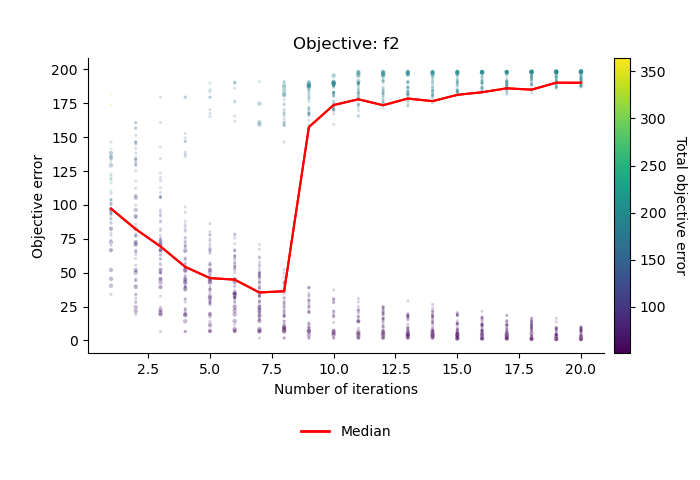

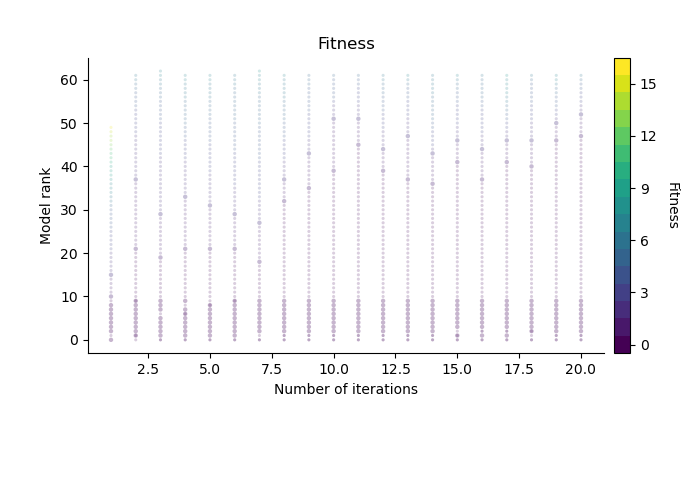

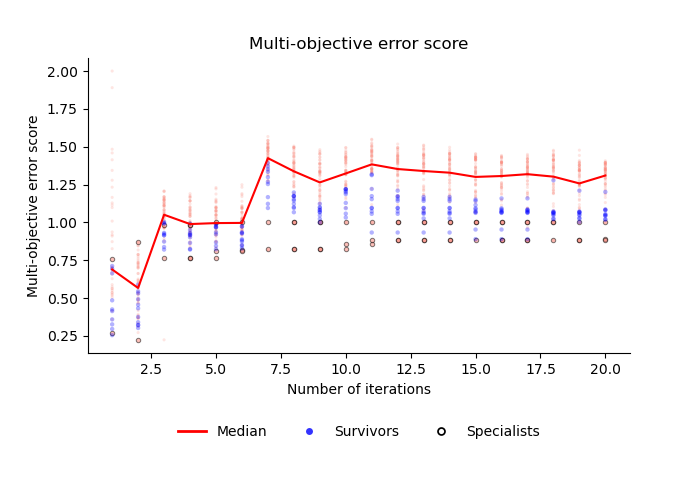

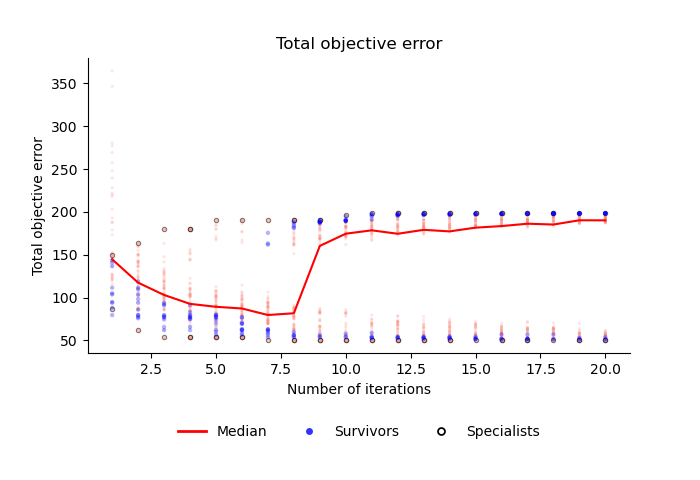

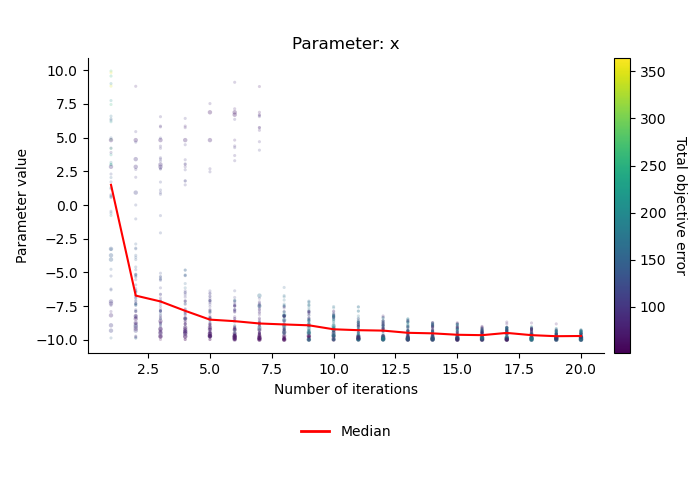

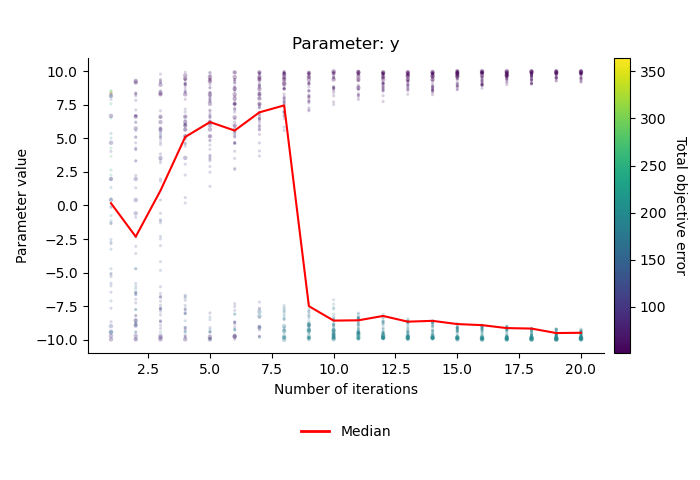

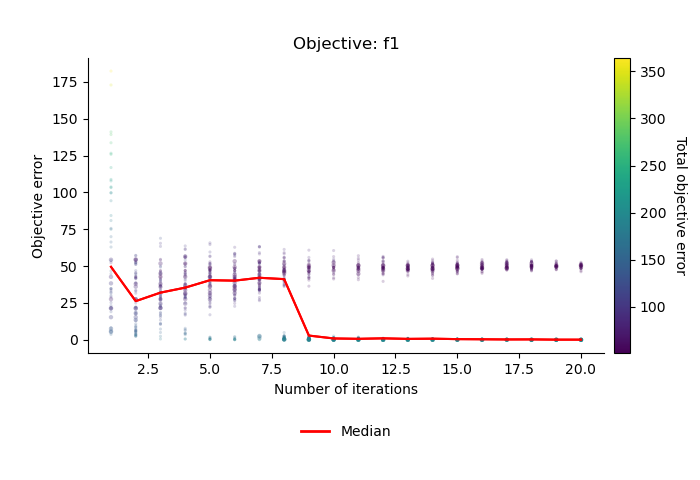

In [16]:
history.plot(['parameters', 'objectives'], energy_scale='linear', energy_color='absolute')

In [19]:
history.survivors[-1][0].__dict__

{'x': array([-9.95503588,  9.99763694]),
 'features': array([], dtype=float64),
 'objectives': array([50.21323216,  0.47316548]),
 'normalized_objectives': array([0.88722944, 0.        ], dtype=float32),
 'energy': 0.88722944,
 'rank': 0,
 'distance': None,
 'fitness': 0,
 'survivor': True,
 'model_id': 873}

In [19]:
report = OptimizationReport(file_path=history_file_path)

In [20]:
report.report_best()

params:
x: -9.955035882653819
y: 9.997636944171035
features:
objectives:
f1: 50.213232163891384
f2: 0.4731654790318771


In [21]:
report.report(report.specialists['f1'])

params:
x: -9.971168223856308
y: -9.903219592238653
features:
objectives:
f1: 0.001972302593174168
f2: 198.7466685120013


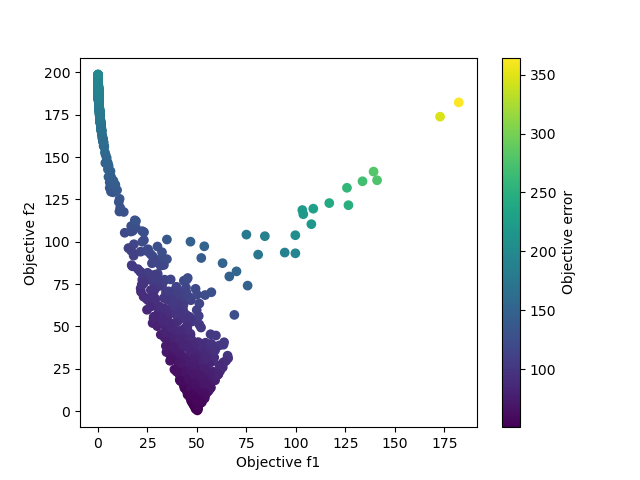

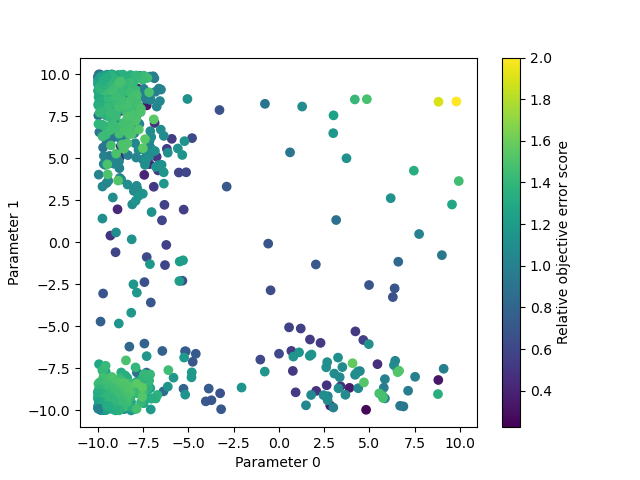

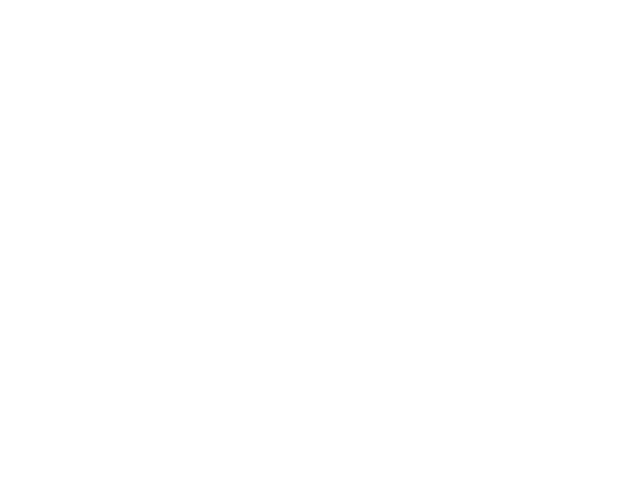

In [31]:
plt.figure()
f1 = [indiv.objectives[0] for gen in history.generations for indiv in gen]
f2 = [indiv.objectives[1] for gen in history.generations for indiv in gen]
c = [i for i, gen in enumerate(history.generations) for indiv in gen]
fitness = [indiv.fitness for gen in history.generations for indiv in gen]
abs_energy = [np.sum(indiv.objectives) for gen in history.generations for indiv in gen]
energy = [indiv.energy for gen in history.generations for indiv in gen]

fig = plt.figure()
plt.scatter(f1, f2, c=abs_energy)
# plt.scatter(f1, f2, c=energy)
plt.colorbar(label='Objective error')
plt.xlabel('Objective f1')
plt.ylabel('Objective f2')
plt.show()

fig = plt.figure()
x = [indiv.x[0] for gen in history.generations for indiv in gen]
y = [indiv.x[1] for gen in history.generations for indiv in gen]
plt.scatter(x, y, c=energy)
plt.xlabel('Parameter 0')
plt.ylabel('Parameter 1')
plt.colorbar(label='Relative objective error score')
plt.show()